## The cosine similarity based on Morgan Fingerprints

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### load precomputed Morgan Fingerprints

In [2]:
df = pd.read_parquet('molecular_descriptors_raw_models_.parquet')

In [3]:
df

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,ChyLine_l2-4_N#CC,ChyLine_l2-4_N#C,ChyLine_l2-4_N#CCC,ChyLine_l2-4_CSC,ChyLine_l2-4_CSCc,ChyLine_l2-4_SCS,ChyLine_l2-4_SCSC,ChyLine_l2-4_CCCc,ChyLine_l2-4_cCCc,ChyLine_l2-4_O=CCc
0,26.682927,5.770088,3.024390,6.178260,153.267812,105.649934,1.844467,5.906402,3.601607,7.350701,...,0,0,0,0,0,0,0,0,0,0
1,25.935484,5.706245,2.580645,4.751892,158.057747,102.435555,1.691055,5.821371,3.519689,7.342506,...,0,0,0,0,0,0,0,0,0,0
2,23.860465,5.661247,2.744186,4.914154,157.443307,94.120542,1.670321,5.779477,3.312805,7.283060,...,0,0,0,0,0,0,0,0,0,0
3,24.764706,5.671282,2.529412,4.450254,158.718230,97.699954,1.650025,5.783676,3.334128,7.311622,...,0,0,0,0,0,0,0,0,0,0
4,24.764706,5.671282,2.588235,4.567901,158.718230,97.699954,1.650025,5.783676,3.349651,7.311622,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,24.700000,5.687590,2.700000,5.132716,156.835814,97.522176,1.703642,5.808375,3.397898,7.304853,...,0,0,0,0,0,0,0,1,0,0
58,25.037037,5.728956,3.111111,6.024234,153.352717,99.029491,1.811354,5.865185,3.286509,7.305058,...,0,0,0,0,0,0,0,0,1,1
59,24.392157,5.698306,2.901961,5.555071,154.914973,96.368631,1.753851,5.827696,3.268504,7.291208,...,0,0,0,0,0,0,0,1,0,0
60,30.727273,5.731982,3.000000,5.630752,153.662396,121.852796,1.930054,5.874975,3.343495,7.353626,...,0,0,0,0,0,0,0,1,0,0


In [4]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Separate columns to standardize and those to keep as is
cols_to_standardize = [col for col in df.columns if "C_FP_" not in col]
cols_to_keep = [col for col in df.columns if "C_FP_" in col]


# Keep the other columns as is
df_unchanged = df[cols_to_keep]

# Remove columns that are entirely zeros
df_unchanged = df_unchanged.loc[:, (df_unchanged != 0).any(axis=0)]

# Ensure original column order
df_final = df_unchanged

# Compute cosine similarity matrix between rows
similarity_matrix = cosine_similarity(df_final.values)

# Convert similarity matrix back to DataFrame for easier interpretation (optional)
similarity_df = pd.DataFrame(similarity_matrix, index=df_final.index, columns=df_final.index)
print(similarity_df)

# Calculate overall average similarity excluding self-similarity
np.fill_diagonal(similarity_matrix, np.nan)
overall_similarity = np.nanmean(similarity_matrix)
print(f"Overall average similarity in dataset: {overall_similarity:.4f}")

          0         1         2         3         4         5         6   \
0   1.000000  0.786852  0.937599  0.748616  0.744633  0.974637  0.936193   
1   0.786852  1.000000  0.731932  0.978589  0.903083  0.816964  0.815317   
2   0.937599  0.731932  1.000000  0.696364  0.712969  0.928977  0.901351   
3   0.748616  0.978589  0.696364  1.000000  0.896153  0.777264  0.775697   
4   0.744633  0.903083  0.712969  0.896153  1.000000  0.775865  0.790253   
..       ...       ...       ...       ...       ...       ...       ...   
57  0.919540  0.821591  0.896478  0.781666  0.796503  0.937493  0.925273   
58  0.965769  0.823441  0.910874  0.783426  0.781686  0.970806  0.937811   
59  0.957895  0.817921  0.919556  0.778174  0.782132  0.967208  0.937713   
60  0.925122  0.827417  0.881924  0.787209  0.793024  0.938246  0.929875   
61  0.919304  0.855813  0.866272  0.823223  0.843670  0.929392  0.911999   

          7         8         9   ...        52        53        54        55  \
0   0.

In [5]:
df_final

,C_FP_1,C_FP_2,C_FP_4,C_FP_14,C_FP_25,C_FP_31,C_FP_32,C_FP_33,C_FP_39,C_FP_45,...,C_FP_1985,C_FP_1991,C_FP_1992,C_FP_1996,C_FP_1999,C_FP_2017,C_FP_2023,C_FP_2029,C_FP_2033,C_FP_2041
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
58,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
59,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
60,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [6]:
# Find minimal similarity value (excluding diagonal)
min_similarity = np.nanmin(similarity_matrix)

print(f"Minimal similarity between any two rows: {min_similarity:.4f}")
# Find maximal similarity value (excluding diagonal)
min_similarity = np.nanmax(similarity_matrix)

print(f"Maximal similarity between any two rows: {min_similarity:.4f}")

Minimal similarity between any two rows: 0.6210
Maximal similarity between any two rows: 0.9897


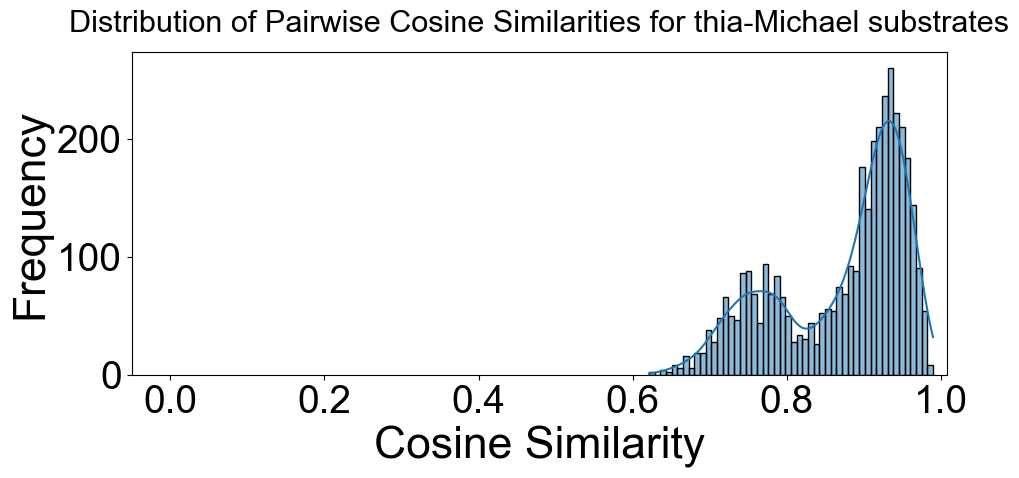

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Remove diagonal values (self-similarity = 1)
np.fill_diagonal(similarity_matrix, np.nan)

# Flatten the matrix and remove nan values to get pairwise similarities
sim_values = similarity_matrix.flatten()
sim_values = sim_values[~np.isnan(sim_values)]

# Set a clean font for better readability
plt.rcParams['font.family'] = 'Arial'  # Or 'Helvetica', 'sans-serif', etc.

# Create figure with specified size
plt.figure(figsize=(10, 5))

# Plot the distribution using seaborn
sns.histplot(sim_values, bins=50, kde=True)

# Customize font sizes for better visibility
plt.title('Distribution of Pairwise Cosine Similarities for thia-Michael substrates', fontsize=22, pad=15)
plt.xlabel('Cosine Similarity', fontsize=32)
plt.xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.xlim(-0.05)
plt.ylabel('Frequency', fontsize=32)
plt.tick_params(axis='both', which='major', labelsize=28)  # Larger tick labels

# Adjust layout to prevent clipping
plt.tight_layout(pad=1.5)  # Add padding to avoid text cutoff

# Save to file with high DPI and tight bounding box
plt.savefig('cosine_similarities_II.svg', bbox_inches='tight', format='svg', dpi=300)

# Show the plot (optional, comment out if only saving)
plt.show()

# Close figure to free memory
plt.close()